# Functions - Images

## Setup

Set up `sys.path` to work while within a subfolder.

In [1]:
import sys
sys.path.append("../..")

Enable this if working within VSCode.

In [2]:
import os

if not os.environ.get("NOTEBOOK_PATH"):
    os.environ["NOTEBOOK_PATH"] = "notebooks/part-1/functions.ipynb"

Manim-related imports.

In [3]:
from manim import *
from manim_utils import *

Set up the image generation cell magic.

In [4]:
%load_ext magics.generate_image

Loaded extension.


## Scenes

### Functions as Machines

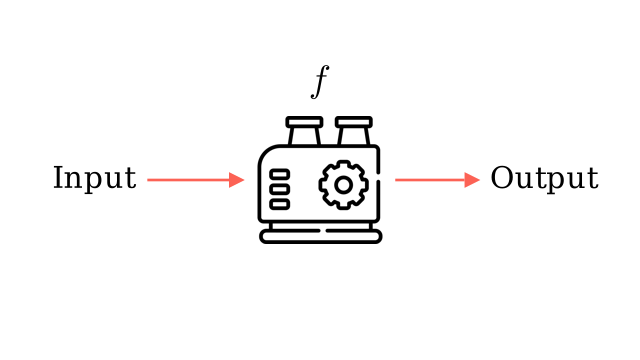

In [33]:
%%generate_image function-as-machine MachineDiagram

ARROW_COLOUR = RED

class MachineDiagram(Scene):
    def construct(self):
        # Create machine
        machine_image = ImageMobject("images/machine.png").scale(0.75)
        machine_label = MathTex("f", font_size=80, color=BLACK).next_to(machine_image, 1.5*UP)
        machine = Group(machine_image, machine_label)
        self.add(machine)

        # Add input
        input_label = Text("Input", color=BLACK)
        input_label.move_to(5*LEFT)
        input_arrow = Arrow(
            input_label.get_right(),
            machine_image.get_left(),
            color=ARROW_COLOUR
        )
        self.add(input_label, input_arrow)

        # Add output
        output_label = Text("Output", color=BLACK)
        output_label.move_to(5*RIGHT)
        output_arrow = Arrow(
            machine_image.get_right(),
            output_label.get_left(),
            color=ARROW_COLOUR
        )
        self.add(output_label, output_arrow)

### The Successor Function
(With the machine analogy.)

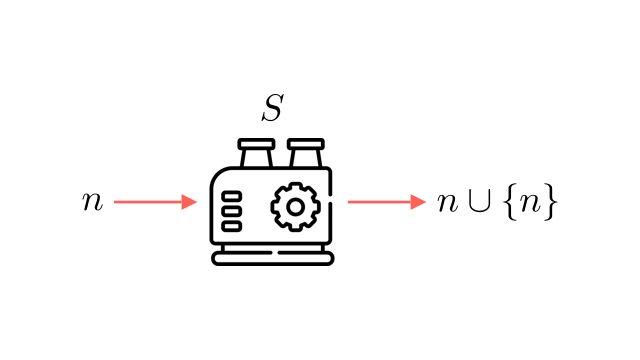

In [41]:
%%generate_image successor-as-machine SuccessorDiagram

ARROW_COLOUR = RED
LABEL_FONT_SIZE = 80

class SuccessorDiagram(Scene):
    def construct(self):
        # Create machine
        machine_image = ImageMobject("images/machine.png").scale(0.75)
        machine_label = MathTex("S", font_size=80, color=BLACK).next_to(machine_image, 1.5*UP)
        machine_group = Group(machine_image, machine_label)

        # Add input
        input_label = MathTex("n", font_size=LABEL_FONT_SIZE, color=BLACK)
        input_label.move_to(4*LEFT)
        input_arrow = Arrow(
            input_label.get_right(),
            machine_image.get_left(),
            color=ARROW_COLOUR
        )
        input_group = Group(input_label, input_arrow)

        # Add output
        output_label = MathTex("n \cup \{n\}", font_size=LABEL_FONT_SIZE, color=BLACK)
        output_label.move_to(5*RIGHT)
        output_arrow = Arrow(
            machine_image.get_right(),
            output_label.get_left(),
            color=ARROW_COLOUR
        )
        output_group = Group(output_label, output_arrow)

        # Center the things
        all_stuff = Group(machine_group, input_group, output_group)
        all_stuff.center()
        self.add(all_stuff)

### The Identity Function

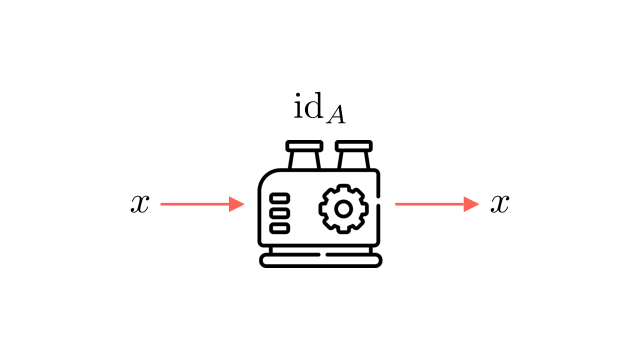

In [42]:
%%generate_image identity-as-machine IdentityFunctionDiagram

ARROW_COLOUR = RED
LABEL_FONT_SIZE = 80

class IdentityFunctionDiagram(Scene):
    def construct(self):
        # Create machine
        machine_image = ImageMobject("images/machine.png").scale(0.75)
        machine_label = MathTex("\mathrm{id}_A", font_size=80, color=BLACK).next_to(machine_image, 1.5*UP)
        machine_group = Group(machine_image, machine_label)

        # Add input
        input_label = MathTex("x", font_size=LABEL_FONT_SIZE, color=BLACK)
        input_label.move_to(4*LEFT)
        input_arrow = Arrow(
            input_label.get_right(),
            machine_image.get_left(),
            color=ARROW_COLOUR
        )
        input_group = Group(input_label, input_arrow)

        # Add output
        output_label = MathTex("x", font_size=LABEL_FONT_SIZE, color=BLACK)
        output_label.move_to(4*RIGHT)
        output_arrow = Arrow(
            machine_image.get_right(),
            output_label.get_left(),
            color=ARROW_COLOUR
        )
        output_group = Group(output_label, output_arrow)

        # Center the things
        all_stuff = Group(machine_group, input_group, output_group)
        all_stuff.center()
        self.add(all_stuff)

### The "Character of" Function
(Using arrow diagram.)

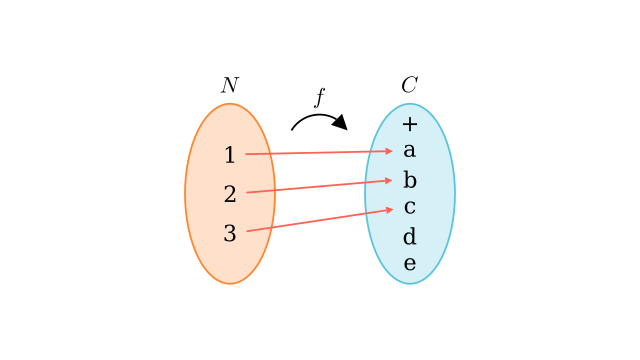

In [15]:
%%generate_image character-of FunctionDiagram

A_FONT_SIZE = 36
B_FONT_SIZE = 36

ARROW_STROKE_WIDTH = 4
ARROW_TIP_RATIO = 0.05

class FunctionDiagram(Scene):
    def construct(self):
        # Create the ellipses
        ellipse_a = Ellipse(width=2, height=4, color=ORANGE)
        ellipse_a.set_fill(ORANGE, opacity=0.25)
        ellipse_a.shift(LEFT * 2)
        
        ellipse_b = Ellipse(width=2, height=4, color=BLUE)
        ellipse_b.set_fill(BLUE, opacity=0.25)
        ellipse_b.shift(RIGHT * 2)
        
        # Create labels for the ellipses
        label_a = MathTex("N", color=BLACK).next_to(ellipse_a, UP)
        label_b = MathTex("C", color=BLACK).next_to(ellipse_b, UP)
        
        # Create elements for sets
        elements_a = ["1", "2", "3"]
        elements_b = ["+", "a", "b", "c", "d", "e"]

        elements_a = [Text(a, font_size=A_FONT_SIZE, color=BLACK) for a in elements_a]
        elements_b = [Text(b, font_size=B_FONT_SIZE, color=BLACK) for b in elements_b]
        
        elements_a = VGroup(*elements_a).arrange(DOWN, buff=0.5).move_to(ellipse_a)
        elements_b = VGroup(*elements_b).arrange(DOWN, buff=0.3).move_to(ellipse_b)
        
        # Create arrows
        arrow_links = [
            (0,1),
            (1,2),
            (2,3)
        ]
        arrows = [
            Arrow(
                elements_a[i].get_right(),
                elements_b[j].get_left(),
                stroke_width=ARROW_STROKE_WIDTH,
                max_tip_length_to_length_ratio=ARROW_TIP_RATIO,
                color=RED
            )
            for i, j in arrow_links
        ]
        arrows = VGroup(*arrows)

        # Add function label above the arrows
        function_label = MathTex("f", color=BLACK).next_to(arrows, 3.5*UP)
        function_label.add(
            CurvedArrow(
                function_label.get_left() + LEFT * 0.5,
                function_label.get_right() + RIGHT * 0.5,
                stroke_width=ARROW_STROKE_WIDTH,
                color=BLACK
            ).flip(LEFT).shift(DOWN * 0.35)
        )

        # Add all elements to the scene
        group = Group(ellipse_a, ellipse_b, label_a, label_b, elements_a, elements_b, arrows, function_label)
        group.center()
        self.add(group)

### The Successor Function
(Using arrow diagram.)

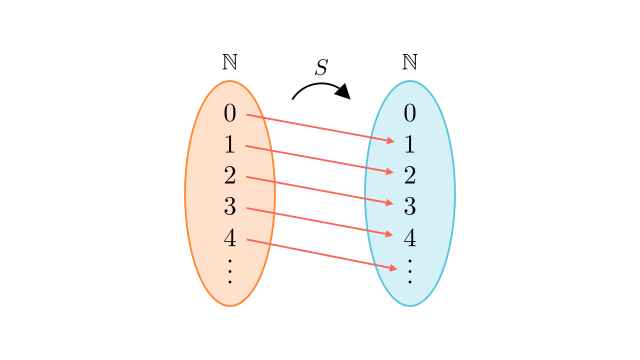

In [10]:
%%generate_image successor FunctionDiagram

A_FONT_SIZE = 56  # NOTE: This is font size using TeX
B_FONT_SIZE = 56

ARROW_STROKE_WIDTH = 4
ARROW_TIP_RATIO = 0.05

class FunctionDiagram(Scene):
    def construct(self):
        # Create the ellipses
        ellipse_a = Ellipse(width=2, height=5, color=ORANGE)
        ellipse_a.set_fill(ORANGE, opacity=0.25)
        ellipse_a.shift(LEFT * 2)
        
        ellipse_b = Ellipse(width=2, height=5, color=BLUE)
        ellipse_b.set_fill(BLUE, opacity=0.25)
        ellipse_b.shift(RIGHT * 2)
        
        # Create labels for the ellipses
        label_a = MathTex("\mathbb{N}", color=BLACK).next_to(ellipse_a, UP)
        label_b = MathTex("\mathbb{N}", color=BLACK).next_to(ellipse_b, UP)
        
        # Create elements for sets
        elements_a = ["0", "1", "2", "3", "4", "\\vdots"]
        elements_b = ["0", "1", "2", "3", "4", "\\vdots"]

        elements_a = [Tex(a, font_size=A_FONT_SIZE, color=BLACK) for a in elements_a]
        elements_b = [Tex(b, font_size=B_FONT_SIZE, color=BLACK) for b in elements_b]
        
        elements_a = VGroup(*elements_a).arrange(DOWN, buff=0.3).move_to(ellipse_a)
        elements_b = VGroup(*elements_b).arrange(DOWN, buff=0.3).move_to(ellipse_b)
        
        # Create arrows
        arrow_links = [
            (0,1),
            (1,2),
            (2,3),
            (3,4),
            (4,5)
        ]
        arrows = [
            Arrow(
                elements_a[i].get_right(),
                elements_b[j].get_left(),
                stroke_width=ARROW_STROKE_WIDTH,
                max_tip_length_to_length_ratio=ARROW_TIP_RATIO,
                color=RED
            )
            for i, j in arrow_links
        ]
        arrows = VGroup(*arrows)

        # Add function label above the arrows
        function_label = MathTex("S", color=BLACK).next_to(arrows, 3.5*UP)
        function_label.add(
            CurvedArrow(
                function_label.get_left() + LEFT * 0.5,
                function_label.get_right() + RIGHT * 0.5,
                stroke_width=ARROW_STROKE_WIDTH,
                color=BLACK
            ).flip(LEFT).shift(DOWN * 0.35)
        )

        # Add all elements to the scene
        group = Group(ellipse_a, ellipse_b, label_a, label_b, elements_a, elements_b, arrows, function_label)
        group.center()
        self.add(group)